<div style="text-align: center;">
    <h1 style="
        background: linear-gradient(135deg, #020b22ff, #33485eff);
        color: white; 
        padding: 15px 30px; 
        border-radius: 500px; 
        font-family: 'Segoe UI', Arial, sans-serif; 
        box-shadow: 0 4px 15px rgba(0,0,0,0.3);
        display: inline-block;
    ">
       Facial Recognition System using Convolutional Neural Networks
    </h1>
</div>


<h4 style="color:#96c9ffff">1. Importing TensorFlow, OpenCV, Matplotlib, NumPy libraries for data manipulation and image preprocessing with ImageDataGenerator for training preparation.</h4>


In [138]:
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

<h4 style="color:#96c9ffff">2. Setting the path for the LFW dataset images directory to the specified location on the local system.</h4>

In [139]:
Dataimages = Path(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\Projects\Facial Recognition System\Data\lfw-deepfunneled")

<h4 style="color:#96c9ffff">3. Selecting a random person directory and a random image file from the LFW dataset directory for further processing.</h4>

In [140]:
person = random.choice([p for p in Dataimages.iterdir() if p.is_dir()])
ImagePath = random.choice([p for p in person.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

<h4 style="color:#96c9ffff">4. Reading a randomly selected image from the file, converting it to both RGB and BGR color formats using OpenCV.</h4>

In [141]:
data = np.fromfile(str(ImagePath), dtype=np.uint8)
Image = cv2.imdecode(data, cv2.IMREAD_COLOR)     
ImgRGB = cv2.cvtColor(Image, cv2.COLOR_BGR2RGB)   
ImgBGR = Image                                 

<h4 style="color:#96c9ffff">5. Displaying the selected person's image before any preprocessing, showing the image in RGB format using Matplotlib.</h4>

Person: Jonathan_Horton


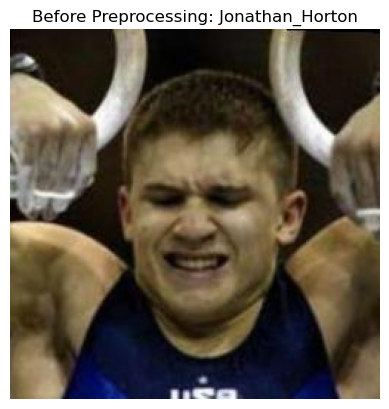

In [142]:
print("Person:", person.name)
plt.imshow(ImgRGB); plt.axis("off"); plt.title(f"Before Preprocessing: {person.name}")
plt.show()

<h4 style="color:#96c9ffff">6. Resizing the selected image to 128x128 and normalizing it to [0,1] for further processing.</h4>

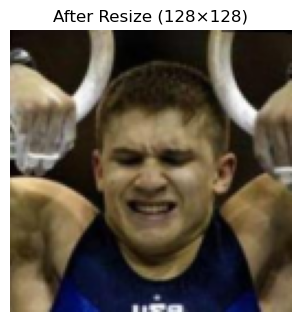

In [ ]:
TargetSize = (128, 128)
ResizedRgb = cv2.resize(ImgRGB, TargetSize, interpolation=cv2.INTER_AREA)
normalization = (ResizedRgb / 255.0).astype("float32")
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(ResizedRgb); plt.axis("off"); plt.title("After Resize (128×128)")
plt.show()

<h4 style="color:#96c9ffff">7. Detecting faces in the image using Haar Cascade Classifier and converting the image to grayscale for face detection.</h4>

In [ ]:
CasCade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
gray = cv2.cvtColor(ImgBGR, cv2.COLOR_BGR2GRAY)
faces = CasCade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40,40))


<h4 style="color:#96c9ffff">8. Detecting faces using Haar Cascade, applying a margin around the detected face, and cropping the face region from the image for further processing.</h4>

Faces detected: 1


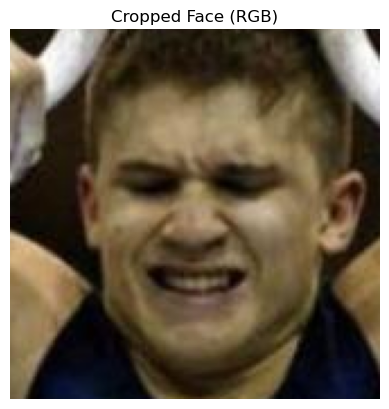

In [145]:
print("Faces detected:", len(faces))

margin = 0.2
Hight, width = ImgBGR.shape[:2]

if len(faces) > 0:
    x, y, w, h = max(faces, key=lambda b: b[2]*b[3]) 
    mx, my = int(margin*w), int(margin*h)
    x1, y1 = max(0, x-mx), max(0, y-my)
    x2, y2 = min(width, x+w+mx), min(Hight, y+h+my)
else:
    side = min(Hight, width)
    y1 = (Hight - side)//2; x1 = (width - side)//2
    x2, y2 = x1 + side, y1 + side

CropBGR = ImgBGR[y1:y2, x1:x2]
CropRGB = cv2.cvtColor(CropBGR, cv2.COLOR_BGR2RGB)

plt.imshow(CropRGB); plt.axis("off"); plt.title("Cropped Face (RGB)")
plt.show()

<h4 style="color:#96c9ffff">9. Drawing the detected face bounding box on the original RGB image (convert to BGR for OpenCV drawing, draw rectangle with (x1,y1)-(x2,y2), then convert back to RGB for display).</h4>

In [146]:
vis = ImgRGB.copy()
vis_bgr = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
cv2.rectangle(vis_bgr, (x1, y1), (x2, y2), (255,0,0), 2)
vis = cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)

<h4 style="color:#96c9ffff">10. Displaying the original image with the face detection rectangle and the cropped face side by side for comparison.</h4>

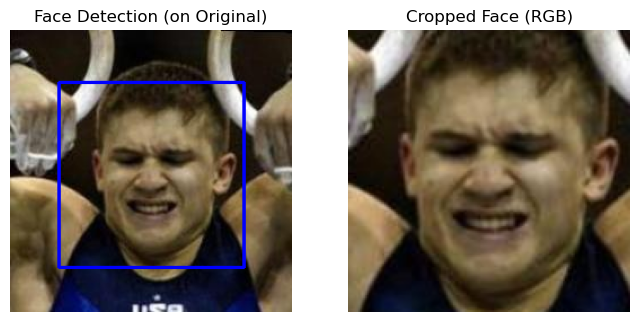

In [147]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(vis);     plt.axis("off"); plt.title("Face Detection (on Original)")
plt.subplot(1,2,2); plt.imshow(CropRGB); plt.axis("off"); plt.title("Cropped Face (RGB)")
plt.show()

<h4 style="color:#96c9ffff">11. Applying CLAHE to the cropped face by equalizing the Y channel in YCrCb space, converting back to RGB, and normalizing to [0,1] for illumination enhancement.</h4>

In [148]:
crop_rgb = CropRGB

apply_clahe = True
if apply_clahe:
    crop_rgb_normalized = crop_rgb / 255.0
    ycc = cv2.cvtColor((crop_rgb_normalized * 255).astype("uint8"), cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycc)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    y_eq = clahe.apply(y)
    ycc_eq = cv2.merge([y_eq, cr, cb])
    eq_rgb = cv2.cvtColor(ycc_eq, cv2.COLOR_YCrCb2RGB).astype("float32") / 255.0
else:
    eq_rgb = crop_rgb / 255.0


<h4 style="color:#96c9ffff">12. Displaying the original cropped face and the cropped face after applying CLAHE side by side to compare the illumination enhancement.</h4>

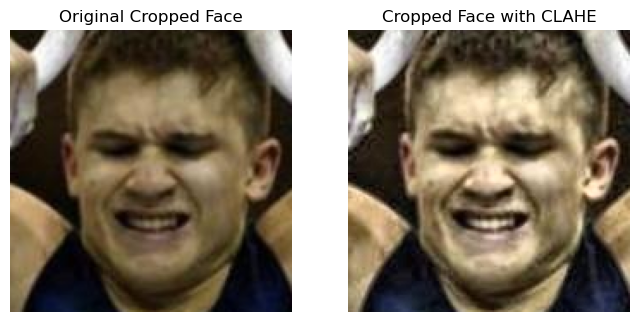

In [149]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(crop_rgb); plt.axis("off"); plt.title("Original Cropped Face")
plt.subplot(1,2,2); plt.imshow(eq_rgb);   plt.axis("off"); plt.title("Cropped Face with CLAHE")
plt.show()
